In [43]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
db=pd.read_csv('datasetler/diabetes.csv')

In [45]:
db.shape

(768, 9)

In [46]:
db.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [47]:
db.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
zeros = (db == 0).sum()
print(zeros)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [49]:
db = db.drop(db[db["Glucose"] == 0].index)


In [50]:
db.shape

(763, 9)

In [78]:
db["Outcome"].value_counts()

Outcome
0    497
1    265
Name: count, dtype: int64

In [51]:
zeros = (db == 0).sum()
print(zeros)

Pregnancies                 111
Glucose                       0
BloodPressure                35
SkinThickness               227
Insulin                     370
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     497
dtype: int64


In [52]:
db["BMI"]=db["BMI"].replace(0,db[db["BMI"]!=0]["BMI"].median())

In [53]:
db["BloodPressure"]=db["BloodPressure"].replace(0,db[db["BloodPressure"]!=0]["BloodPressure"].median())

In [54]:
zero=(db==0).sum()
print(zero)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                     370
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     497
dtype: int64


In [55]:
db["SkinThickness"]=db["SkinThickness"].replace(0,db[db["SkinThickness"]!=0]["SkinThickness"].median())
db["Insulin"]=db["Insulin"].replace(0,db[db["Insulin"]!=0]["Insulin"].median())


In [56]:
zero=(db==0).sum()
print(zero)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     497
dtype: int64


In [79]:
hastalar = db[db['Outcome'] == 1]

In [80]:
# 3. Orijinal tablo ile bu seçtiğin hastaları birleştir (Alt alta ekle)
# ignore_index=True diyerek satır numaralarını (0, 1, 2...) yeniden düzenleriz
db= pd.concat([db, hastalar], ignore_index=True)

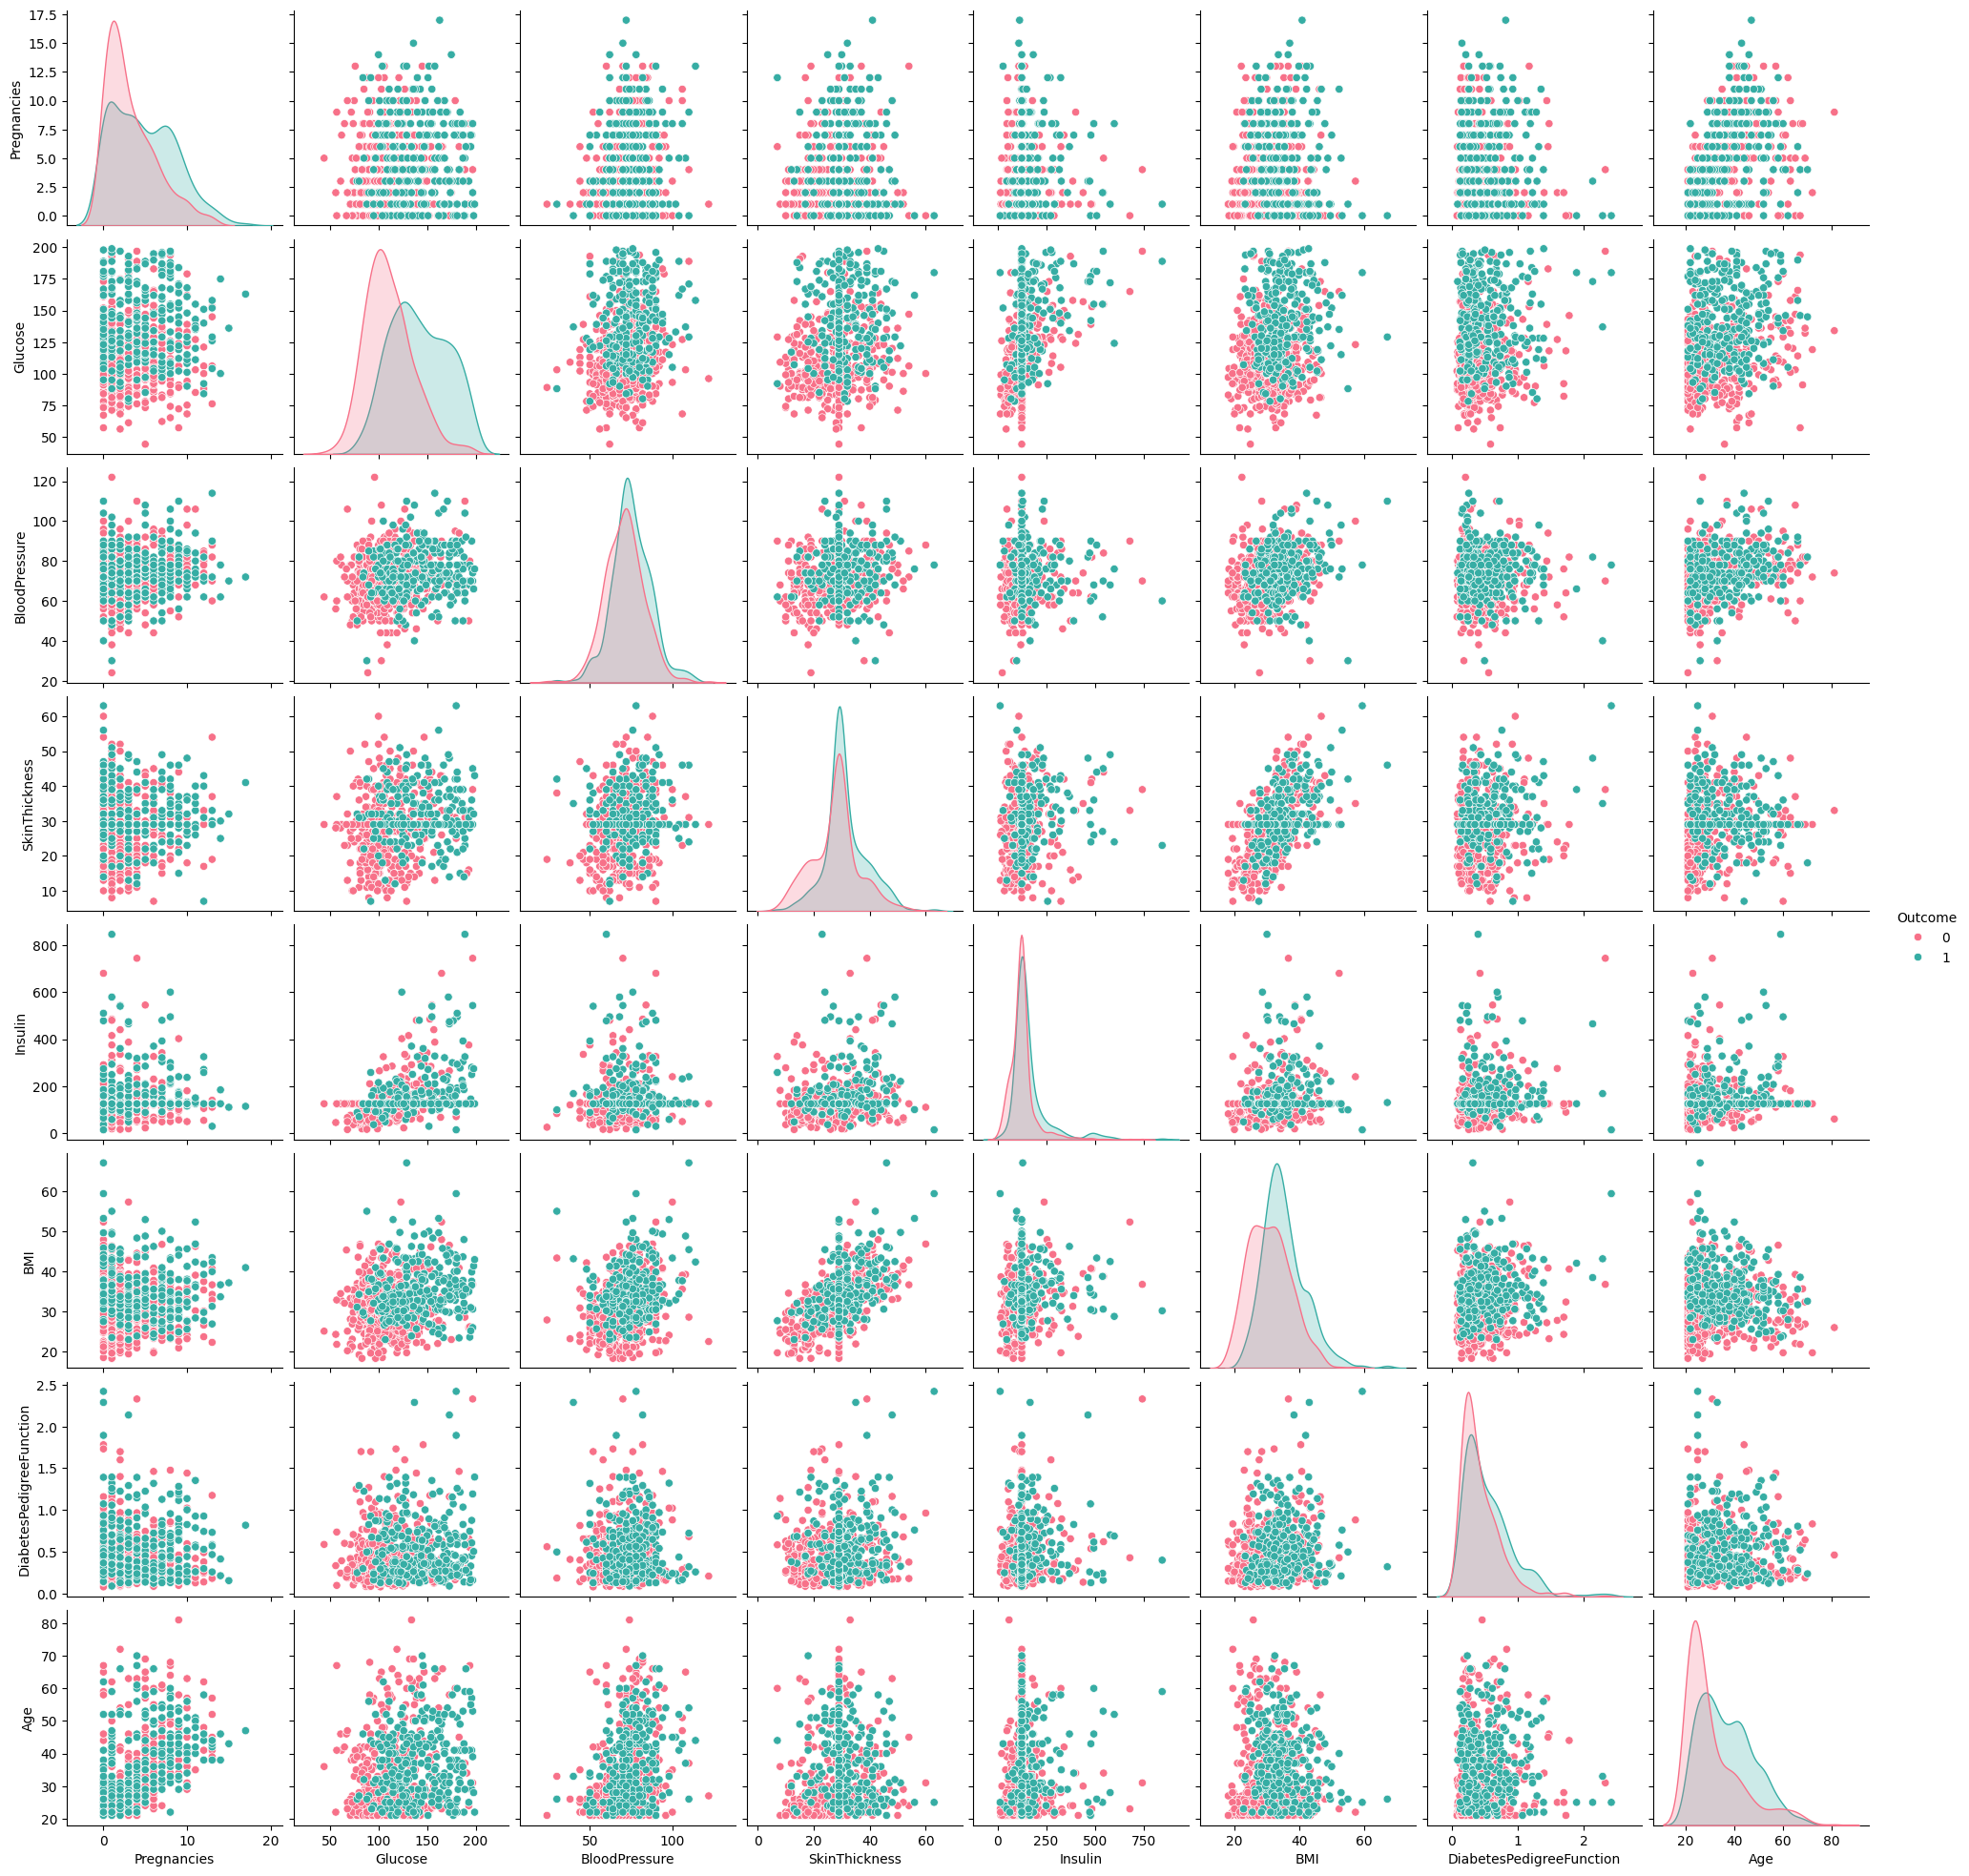

In [81]:
sns.pairplot(db, hue="Outcome", palette="husl", diag_kind="kde")

<Axes: xlabel='SkinThickness', ylabel='Age'>

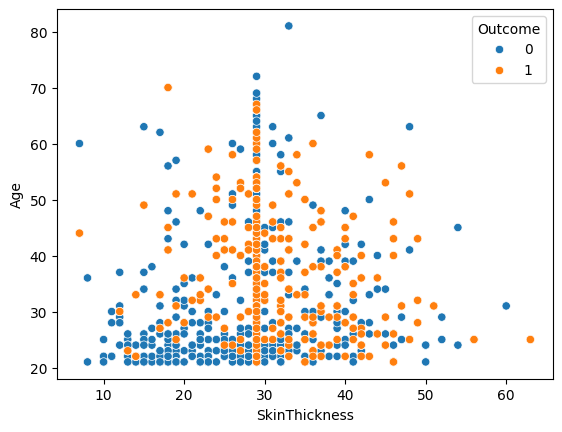

In [82]:
sns.scatterplot(data=db, x="SkinThickness", y="Age", hue="Outcome")

In [83]:
db=db[db["SkinThickness"]<80]

<Axes: xlabel='SkinThickness', ylabel='Age'>

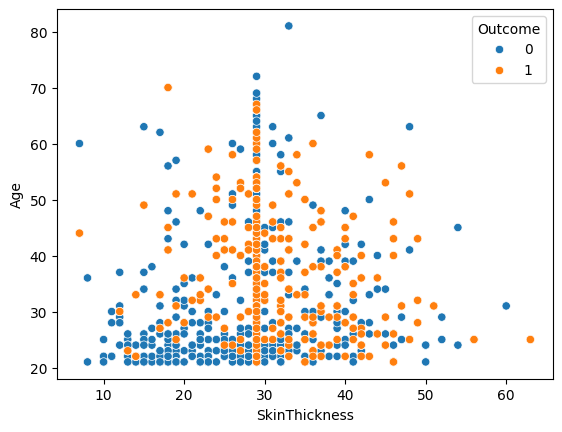

In [84]:
sns.scatterplot(data=db, x="SkinThickness", y="Age", hue="Outcome")

In [85]:
plt.figure(figsize=(10, 8))
correlation_matrix = db.corr()

<Figure size 1000x800 with 0 Axes>

Text(0.5, 1.0, 'Hangi Veri Hangisiyle İlişkili?')

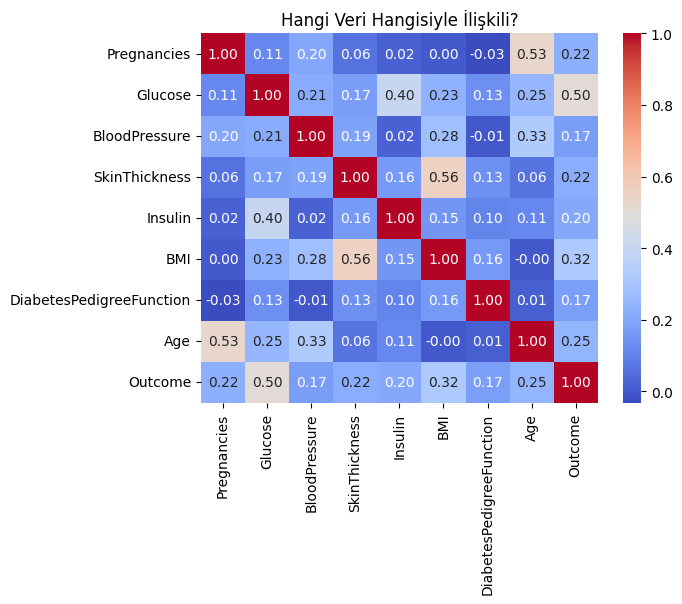

In [86]:
# Isı haritası olarak çiziyoruz
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Hangi Veri Hangisiyle İlişkili?')

In [87]:
db.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [88]:
X=db.drop("Outcome",axis=1)
y=db["Outcome"]

In [89]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=25)


In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
svm_model = SVC(kernel='rbf', C=1.0, probability=True)
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [94]:
y_pred=svm_model.predict(X_test_scaled)

In [95]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [96]:
print("Doğruluk Skoru (Accuracy):", accuracy_score(y_test, y_pred))
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

Doğruluk Skoru (Accuracy): 0.7815533980582524

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.80      0.72      0.76        97
           1       0.77      0.83      0.80       109

    accuracy                           0.78       206
   macro avg       0.78      0.78      0.78       206
weighted avg       0.78      0.78      0.78       206

